### 4.3 앙상블 학습 개요

**Voting Classifier**

위스콘신 유방암 데이터 로드

In [8]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


VotingClassifier로 개별모델은 로지스틱 회귀와 KNN을 보팅방식으로 결합하고 성능 비교

In [9]:
# 개별 모델은 Logistic Regerssion와 KNN
lr_clf = LogisticRegression()
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR',lr_clf),{'KNN',knn_clf}],voting='soft')

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

vo_clf.fit(X_train,y_train)
pred = vo_clf.predict(X_test)
print("Voting 분류기 정확도 {0:.4f}".format(accuracy_score(y_test,pred)))

# 개별 모델의 학습/예측/평가
classifiers = [lr_clf, knn_clf]
for classifier in classifiers :
    classifier.fit(X_train,y_train)
    pred = classifier.predict(X_test)
    class_name = classifier.__class__.__name__
    print('{0} 정확도 : {1:.4f}'.format(class_name, accuracy_score(y_test,pred)))
    

Voting 분류기 정확도 0.9474
LogisticRegression 정확도 : 0.9386
KNeighborsClassifier 정확도 : 0.9386


### 4.4 Random Forest

In [12]:
import pandas as pd


def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1]) 
                                                                                         if x[1] >0 else x[0] ,  axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

def get_human_dataset( ):
    
    # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv('./human_activity/features.txt',sep='\s+',
                        header=None,names=['column_index','column_name'])
    
    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame생성. 
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # DataFrame에 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 학습 피처 데이터 셋과 테스트 피처 데이터을 DataFrame으로 로딩. 컬럼명은 feature_name 적용
    X_train = pd.read_csv('./human_activity/train/X_train.txt',sep='\s+', names=feature_name )
    X_test = pd.read_csv('./human_activity/test/X_test.txt',sep='\s+', names=feature_name)
    
    # 학습 레이블과 테스트 레이블 데이터을 DataFrame으로 로딩하고 컬럼명은 action으로 부여
    y_train = pd.read_csv('./human_activity/train/y_train.txt',sep='\s+',header=None,names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt',sep='\s+',header=None,names=['action'])
    
    # 로드된 학습/테스트용 DataFrame을 모두 반환 
    return X_train, X_test, y_train, y_test


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()
params = {
    'max_depth' : [8,16,24],
    'min_samples_leaf' : [1,6,12],
    'min_samples_split' : [2,8,16]
}

rf_clf = RandomForestClassifier(n_estimators=100,random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train,y_train)

print('최적 하이퍼 파라미터 : {0}'.format(grid_cv.best_params_))
print('최적 예측 정확도 : {0:.4f}'.format(grid_cv.best_score_))


/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packag

최적 하이퍼 파라미터 : {'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 16}
최적 예측 정확도 : 0.9159


In [16]:
rf_clf1 = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf= 6, min_samples_split=16, random_state=0)
rf_clf1.fit(X_train,y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도 {0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도 0.9175


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

ftr_importance_values = rf_clf1.feature_importances_
ftr_importance_values = pd.Series(ftr_importance_values, index=X_train.columns)
top_20 = ftr_importance_values.sort_values(ascending=False)[:20]
top_20

angle(X,gravityMean)              0.039707
tGravityAcc-mean()-Y              0.033614
tGravityAcc-min()-X               0.032477
tGravityAcc-max()-X               0.027585
angle(Y,gravityMean)              0.027186
tGravityAcc-energy()-X            0.026499
tGravityAcc-max()-Y               0.026263
tGravityAcc-mean()-X              0.026224
fBodyAccJerk-bandsEnergy()-1,8    0.021112
tGravityAcc-min()-Y               0.019616
tGravityAccMag-std()              0.017156
tGravityAcc-energy()-Y            0.015000
tBodyAccJerk-entropy()-X          0.014469
tGravityAcc-arCoeff()-Z,1         0.013681
tGravityAcc-max()-Z               0.011714
tBodyAcc-max()-X                  0.011163
fBodyAccJerk-mean()-X             0.010055
tGravityAcc-arCoeff()-Y,1         0.009768
fBodyAcc-entropy()-X              0.009635
tGravityAcc-mean()-Z              0.009627
dtype: float64

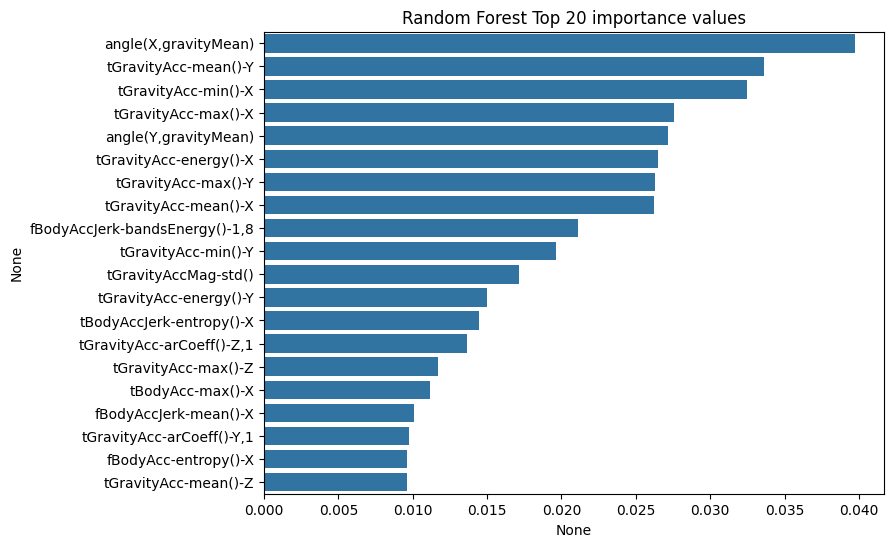

In [33]:
plt.figure(figsize=(8,6))
plt.title('Random Forest Top 20 importance values')
sns.barplot(x=top_20, y=top_20.index)
plt.show()

### 4.5 GBM(Gradient Boosting Machine)

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train,y_train)
pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, pred)

end_time = time.time()


print('GBM 정확도 : {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간 : {0:.1f}'.format(end_time - start_time) )


GBM 정확도 : 0.9379
GBM 수행 시간 : 446.6


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators' : [100, 500],
    'learning_rate' : [0.05, 0.1]
}
grid_cv = GridSearchCV(gb_clf,param_grid = params, cv=2 , verbose = 1)
grid_cv.fit(X_train,y_train)

print('최적 하이퍼 파라미터 : {0}'.format(grid_cv.best_params_))
print('최적 예측 정확도 {0:.4f}'.format(grid_cv.best_score_))

Fitting 2 folds for each of 4 candidates, totalling 8 fits


In [ ]:
gb_pred = grid_cv.best_estimator_.predict(X_test)
gb_accuracy = accuracy_score(y_test,gb_pred)

print('GBM 정확도 {0:.4f}'.format(gb_accuracy))